In [1]:
# Same as we did in classification but just for regression model

In [2]:
# Impot necessary libraries 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow 
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Input
from tensorflow.keras.optimizers import Adam


In [3]:
# We will be creating our own aritificial dataset for this problem

In [4]:
X_train = np.linspace(-1, 1, 20)

In [5]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  ,
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475,
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [6]:
X_test = np.linspace(-1, 1, 20)

In [7]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

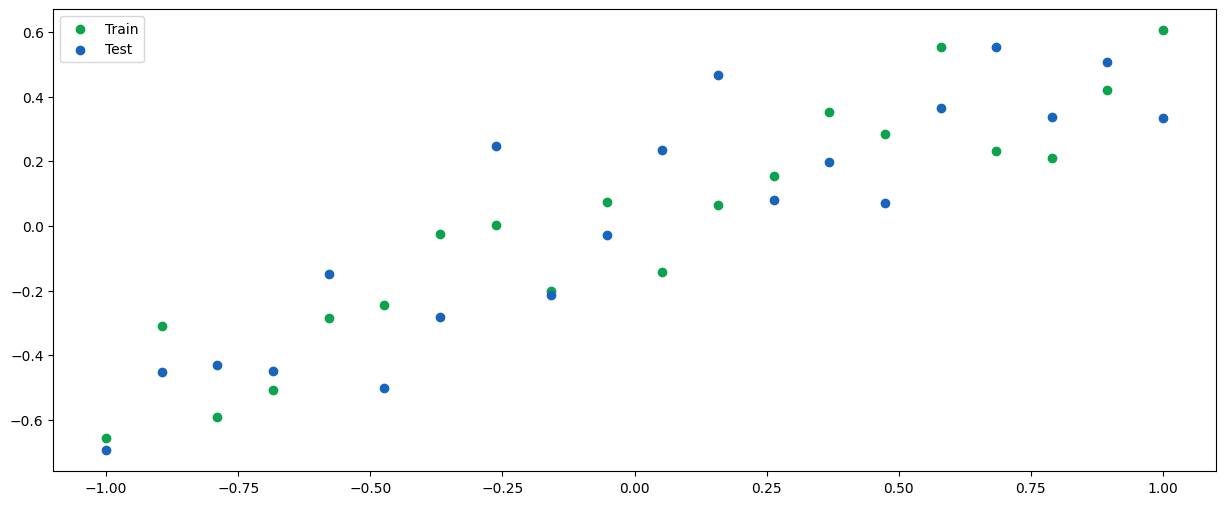

In [9]:
# Now let's visualize this points
plt.figure(figsize=(15,6))
plt.scatter(X_train, y_train, c="#0CA34D", label='Train')
plt.scatter(X_test, y_test, c="#1965BB", label='Test')
plt.legend()
plt.show()

In [18]:
# Now let's create our model
model = Sequential()
model.add(Input(shape=(1,)))
model.add(Dense(128, activation="relu"))
model.add(Dense(128, activation="relu"))
model.add(Dense(1, activation="linear"))

In [19]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
adam = Adam(learning_rate=0.01) # Tweaking learning rate

In [ ]:
# Now compile using loss as mse and metric also as mse and also passing adam
model.compile(loss='mse', optimizer=adam, metrics=['mse'])

In [25]:
history = model.fit(
                    X_train, y_train,
                    epochs=500,
                    validation_data = (X_test, y_test),
                    verbose=1
                    )

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 0.1303 - mse: 0.1303 - val_loss: 0.0284 - val_mse: 0.0284
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - loss: 0.0182 - mse: 0.0182 - val_loss: 0.0513 - val_mse: 0.0513
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - loss: 0.0402 - mse: 0.0402 - val_loss: 0.0352 - val_mse: 0.0352
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 0.0229 - mse: 0.0229 - val_loss: 0.0322 - val_mse: 0.0322
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - loss: 0.0189 - mse: 0.0189 - val_loss: 0.0397 - val_mse: 0.0397
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - loss: 0.0262 - mse: 0.0262 - val_loss: 0.0379 - val_mse: 0.0379
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.0246 - mse: 0.0246 - val_loss: 0.0317 - val_mse: 0.0317
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 0.0187 - mse: 0.0187 - val_loss: 0.0296 - val_mse: 0.0296
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - loss: 0.0169 -

In [26]:
# Now lets evaluate the model

_, train_mse = model.evaluate(X_train, y_train, verbose=0)
_, test_mse = model.evaluate(X_test, y_test, verbose=0)

print('RMSE for : ')
print('Train: {}, Test: {}'.format(train_mse, test_mse))

RMSE for : 
Train: 0.002927986439317465, Test: 0.04528011381626129


In [39]:
# We can clearly see the difference between both the rmse values
test_mse - train_mse

0.033956496976315975

In [27]:
# Make predictions on the testing set 
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step


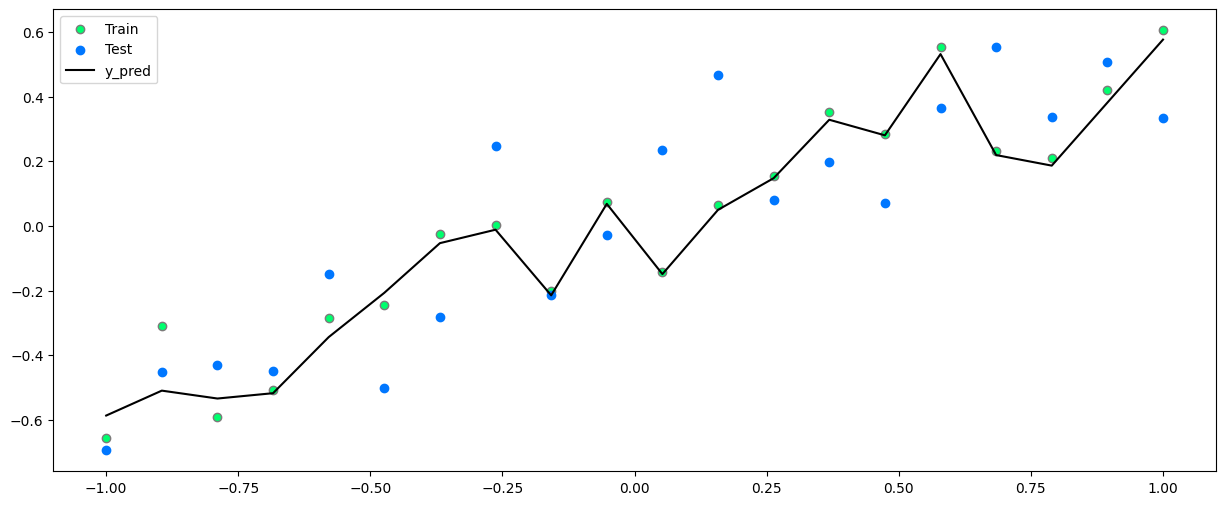

In [33]:
plt.figure(figsize=(15,6))
plt.scatter(X_train, y_train, c="#00FF6E", label='Train',edgecolors="#7C7A7A")
plt.scatter(X_test, y_test, c="#0077FF", label='Test')
plt.plot(X_test,y_pred,c="#000000",label='y_pred')
plt.legend()
plt.show()

In [34]:
# As we can clearly see that line is overfiing here trying to learn values 

In [35]:
# Let's now repeat the process but by dropping values

In [36]:

model = Sequential()

model.add(Input(shape=(1,)))

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.2))  # < -- Dropping by this much ratio
model.add(Dense(128, activation="relu"))
model.add(Dropout(0.2))  # < -- Dropping by this much ratio 

model.add(Dense(1, activation="linear"))

adam = Adam(learning_rate=0.01)

model.compile(loss='mse', optimizer=adam, metrics=['mse'])

In [37]:
history = model.fit(
                    X_train, y_train,
                    epochs=500,
                    validation_data = (X_test, y_test),
                    verbose=1
                    )

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - loss: 0.2097 - mse: 0.2097 - val_loss: 0.0490 - val_mse: 0.0490
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 0.0399 - mse: 0.0399 - val_loss: 0.0484 - val_mse: 0.0484
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - loss: 0.0373 - mse: 0.0373 - val_loss: 0.0569 - val_mse: 0.0569
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step - loss: 0.0672 - mse: 0.0672 - val_loss: 0.0455 - val_mse: 0.0455
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.0348 - mse: 0.0348 - val_loss: 0.0373 - val_mse: 0.0373
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - loss: 0.0243 - mse: 0.0243 - val_loss: 0.0344 - val_mse: 0.0344
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 0.0192 - mse: 0.0192 - val_loss: 0.0358 - val_mse: 0.0358
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 0.0246 - mse: 0.0246 - val_loss: 0.0382 - val_mse: 0.0382
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 0.0265 -

In [38]:
# Now lets evaluate the model

_, train_mse = model.evaluate(X_train, y_train, verbose=0)
_, test_mse = model.evaluate(X_test, y_test, verbose=0)

print('RMSE for : ')
print('Train: {}, Test: {}'.format(train_mse, test_mse))

RMSE for : 
Train: 0.010032632388174534, Test: 0.04398912936449051


In [40]:
# We can clearly see the difference between both the rmse values
test_mse - train_mse

0.033956496976315975

In [41]:
# Make predictions on the testing set 
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step


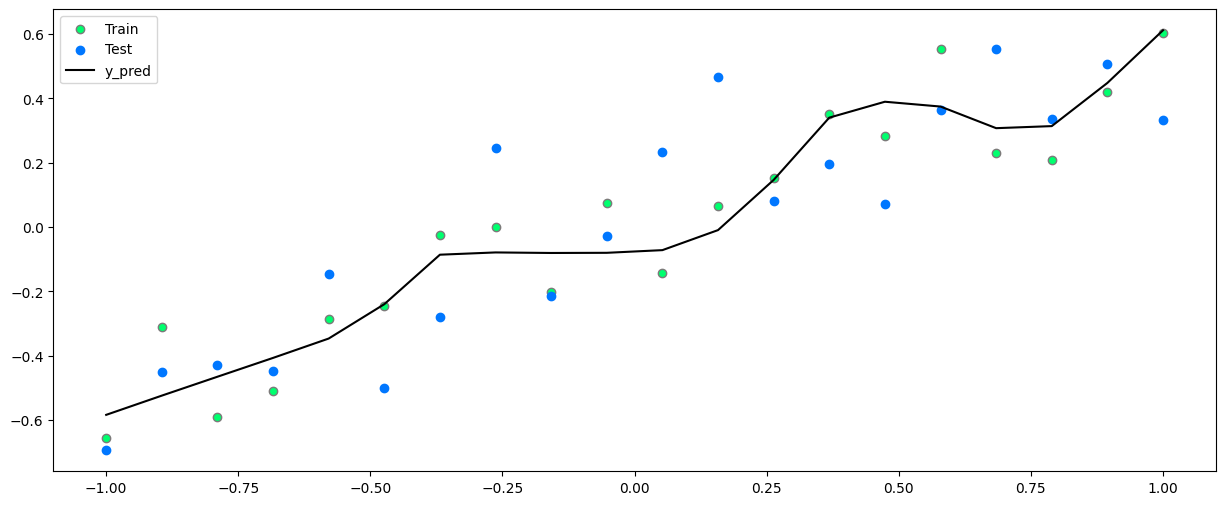

In [42]:
plt.figure(figsize=(15,6))
plt.scatter(X_train, y_train, c="#00FF6E", label='Train',edgecolors="#7C7A7A")
plt.scatter(X_test, y_test, c="#0077FF", label='Test')
plt.plot(X_test,y_pred,c="#000000",label='y_pred')
plt.legend()
plt.show()

In [44]:
# Clearly we can see how the line smoothened here and now it's not learning values but patterns